# CNN/DailyMail Dataset — Context and Problem

## What is the cnn_dailymail dataset?

The **cnn_dailymail** dataset available on [Hugging Face Datasets](https://huggingface.co/datasets/cnn_dailymail) is a collection of news articles from **CNN** and **DailyMail**, paired with their highlights (summaries) written by human journalists. It contains approximately 311,971 article-summary pairs split into:

| Split | Examples |
|---|---|
| Train | 287,113 |
| Validation | 13,368 |
| Test | 11,490 |

Each example has three fields:
- ****: the full body of the news article (multiple paragraphs).
- ****: human-written summary with key points (bullet points joined by ).
- **uid=197609(emanu) gid=197609 groups=197609**: unique identifier.

## What problem does it allow us to solve?

Training a model on this dataset addresses the task of **abstractive text summarization in English**: given a long article, the model must generate a short, coherent summary that captures the most relevant information.

This is a **sequence-to-sequence (seq2seq)** problem: the input sequence is the article and the output sequence is the summary. It is relevant in applications such as:
- News readers that condense long articles.
- Media monitoring systems.
- Academic research assistants.

The standard benchmark for measuring the quality of generated summaries is **ROUGE** (Recall-Oriented Understudy for Gisting Evaluation), which measures n-gram overlap between the generated summary and the reference.


# 1. Data transformation process, test split and vocabulary creation

In [1]:
import os
import re
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

## Loading the Dataset from Hugging Face

We use the Hugging Face  library to directly download the **cnn_dailymail v3.0.0** dataset. Version 3.0.0 is the most widely used in academic benchmarks because it includes the full article text (unlike earlier versions that only used anonymized entities).

The dataset already comes split into **train / validation / test**, so manual splitting is not needed.


In [2]:
from datasets import load_dataset

print("Loading CNN/DailyMail from Hugging Face...")
hf_dataset = load_dataset("cnn_dailymail", "3.0.0")

# Convert to a list of (article, highlights) tuples to keep
# the same interface as the rest of the pipeline
train_data = [(ex["article"], ex["highlights"]) for ex in hf_dataset["train"]]
val_data   = [(ex["article"], ex["highlights"]) for ex in hf_dataset["validation"]]
test_data  = [(ex["article"], ex["highlights"]) for ex in hf_dataset["test"]]

print(f"Train:      {len(train_data):,}")
print(f"Validation: {len(val_data):,}")
print(f"Test:       {len(test_data):,}")


C:\Users\emanu\encoder-decoder-ml\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading CNN/DailyMail from Hugging Face...


C:\Users\emanu\encoder-decoder-ml\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\emanu\.cache\huggingface\hub\datasets--cnn_dailymail. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating test split: 100%|██████████████████████████████████████████████████████████████████████████████████████

Train:      287,113
Validation: 13,368
Test:       11,490


In [3]:
# Data observation
article, highlights = train_data[0]

print('---- ARTICLE (first 500 chars) ----')
print(article[:500])
print('\n---- HIGHLIGHTS (summary) ----')
print(highlights)

---- ARTICLE (first 500 chars) ----
LONDON, England (Reuters) -- Harry Potter star Daniel Radcliffe gains access to a reported £20 million ($41.1 million) fortune as he turns 18 on Monday, but he insists the money won't cast a spell on him. Daniel Radcliffe as Harry Potter in "Harry Potter and the Order of the Phoenix" To the disappointment of gossip columnists around the world, the young actor says he has no plans to fritter his cash away on fast cars, drink and celebrity parties. "I don't plan to be one of those people who, as s

---- HIGHLIGHTS (summary) ----
Harry Potter star Daniel Radcliffe gets £20M fortune as he turns 18 Monday .
Young actor says he has no plans to fritter his cash away .
Radcliffe's earnings from first five Potter films have been held in trust fund .


## Analyze Sequence Lengths

Choose `MAX_ARTICLE_LEN` and `MAX_SUMMARY_LEN` that cover most examples
without wasting memory on very long outliers. 

10,000 stories will be a sufficient sample for this study on the data.

--- Article word counts ---
  Mean:   694
  Median: 635
  90th %: 1172
  Max:    2116

--- Summary word counts ---
  Mean:   52
  Median: 48
  90th %: 77
  Max:    1106


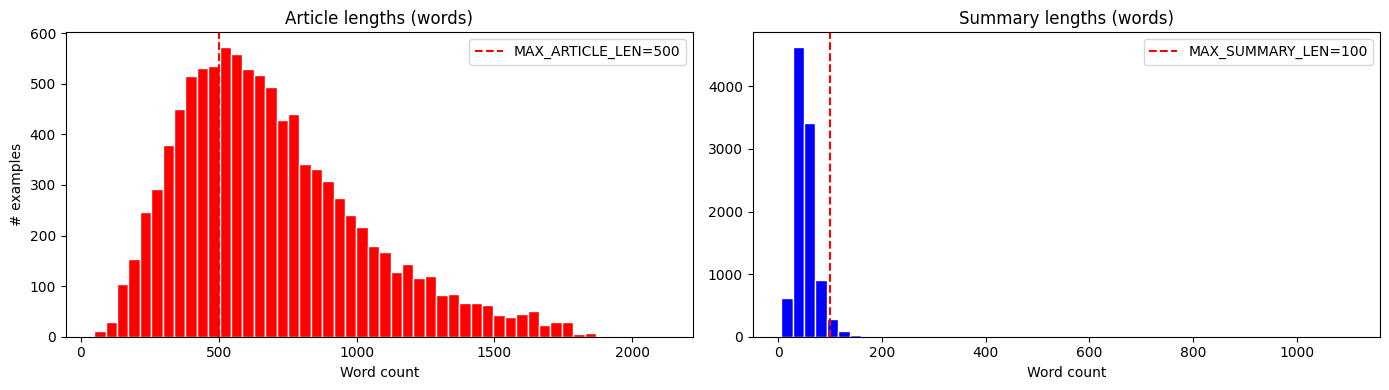

In [4]:
sample = random.sample(train_data, min(10_000, len(train_data)))

article_lengths = [len(art.split())  for art, _ in sample]
summary_lengths = [len(hlt.split())  for _, hlt in sample]

print('--- Article word counts ---')
print(f'  Mean:   {np.mean(article_lengths):.0f}')
print(f'  Median: {np.median(article_lengths):.0f}')
print(f'  90th %: {np.percentile(article_lengths, 90):.0f}')
print(f'  Max:    {np.max(article_lengths)}')

print('\n--- Summary word counts ---')
print(f'  Mean:   {np.mean(summary_lengths):.0f}')
print(f'  Median: {np.median(summary_lengths):.0f}')
print(f'  90th %: {np.percentile(summary_lengths, 90):.0f}')
print(f'  Max:    {np.max(summary_lengths)}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(article_lengths, bins=50, color='red', edgecolor='white')
axes[0].axvline(500, color='red', linestyle='--', label='MAX_ARTICLE_LEN=500')
axes[0].set_title('Article lengths (words)')
axes[0].set_xlabel('Word count')
axes[0].set_ylabel('# examples')
axes[0].legend()

axes[1].hist(summary_lengths, bins=50, color='blue', edgecolor='white')
axes[1].axvline(100, color='red', linestyle='--', label='MAX_SUMMARY_LEN=100')
axes[1].set_title('Summary lengths (words)')
axes[1].set_xlabel('Word count')
axes[1].legend()

plt.tight_layout()
plt.show()

## Dataset Splits

Hugging Face already provides the three standard benchmark splits:
- **Train**: examples used to update the model weights.
- **Validation**: used to monitor overfitting during training.
- **Test**: final evaluation (only used at the end, never during training).


In [5]:
# The Hugging Face dataset already comes with predefined splits.
# Print sizes to confirm the data loaded correctly.
print(f"Train:      {len(train_data):,}")
print(f"Validation: {len(val_data):,}")
print(f"Test:       {len(test_data):,}")


Train:      287,113
Validation: 13,368
Test:       11,490


## Text Cleaning

- Lowercase everything
- Removes characters that carry no meaning.
- Collapses extra whitespace

In order to be able to instruct the decoder where to start and where to end in its process, summaries get `<start>` and `<end>` tokens in their respective positions 

In [6]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s.,!?'\"\-]", ' ', text)
    text = re.sub(r'([.,!?])', r' \1 ', text)  # Add space before punctuation, this helps identify tokens like supervise, like "supervise" and "," instead of "supervise,"
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def preprocess_article(text):
    return clean_text(text)

def preprocess_summary(text):
    cleaned = clean_text(text)
    return f'<start> {cleaned} <end>'

art_raw, hlt_raw = train_data[0]

print('RAW article (first 200 chars):')
print(art_raw[:200])
print('\nCLEANED article (first 200 chars):')
print(preprocess_article(art_raw)[:200])
print('\nRAW summary:')
print(hlt_raw)
print('\nCLEANED summary (with special tokens):')
print(preprocess_summary(hlt_raw))

RAW article (first 200 chars):
LONDON, England (Reuters) -- Harry Potter star Daniel Radcliffe gains access to a reported £20 million ($41.1 million) fortune as he turns 18 on Monday, but he insists the money won't cast a spell on 

CLEANED article (first 200 chars):
london , england reuters -- harry potter star daniel radcliffe gains access to a reported 20 million 41 . 1 million fortune as he turns 18 on monday , but he insists the money won't cast a spell on hi

RAW summary:
Harry Potter star Daniel Radcliffe gets £20M fortune as he turns 18 Monday .
Young actor says he has no plans to fritter his cash away .
Radcliffe's earnings from first five Potter films have been held in trust fund .

CLEANED summary (with special tokens):
<start> harry potter star daniel radcliffe gets 20m fortune as he turns 18 monday . young actor says he has no plans to fritter his cash away . radcliffe's earnings from first five potter films have been held in trust fund . <end>


## Dictionary/Vocabulary creation 

A vocabulary maps every word to a unique integer. Recommendations state that we define <pad> and <unk> tokens too:

| Token | Index | Meaning |
|---|---|---|
| `<pad>` | 0 | Padding |
| `<unk>` | 1 | Unknown |
| `<start>` | 2 | Signals the decoder to begin generating |
| `<end>` | 3 | Signals the decoder to stop generating |

The vocabulary is built **only from training data** 

### Hyperparameters
| Const| Value | Reasoning |
|---|---|---|
| MAX_ARTICLE_LEN | 500 | Most articles fall under or in the 500 word mark (It can be raised for a more rigorous approach)|
| MAX_SUMMARY_LEN | 100 | Most summaries fall under the 100 word mark (Gathering mostly all of them due to their nature) |
| MIN_WORD_FREQ  | 5 | Minimum freq for a word in order for it to not be considered <unk> avoids mapping weird words |
| MAX_VOCAB_SIZE | 50_000 | Hard ceiling for the dictionary/vocabulary, recommended |

In [7]:
# Hyperparameters
MAX_ARTICLE_LEN = 500
MAX_SUMMARY_LEN = 100
MIN_WORD_FREQ   = 5
MAX_VOCAB_SIZE  = 50_000

# Special tokens
PAD_TOKEN, UNK_TOKEN, START_TOKEN, END_TOKEN = '<pad>', '<unk>', '<start>', '<end>'
SPECIAL_TOKENS = [PAD_TOKEN, UNK_TOKEN, START_TOKEN, END_TOKEN]
PAD_IDX, UNK_IDX, START_IDX, END_IDX = 0, 1, 2, 3

word_counts = Counter()

for art, hlt in train_data:
    word_counts.update(preprocess_article(art).split())
    word_counts.update(preprocess_summary(hlt).split())

print(f'Unique tokens before filtering: {len(word_counts):,}')

frequent_words = [
    word for word, count in word_counts.most_common(MAX_VOCAB_SIZE)
    if count >= MIN_WORD_FREQ
]

# Definition of the word2idx vocabulary
word2idx = {tok: i for i, tok in enumerate(SPECIAL_TOKENS)}
for word in frequent_words:
    if word not in word2idx:
        word2idx[word] = len(word2idx)

idx2word = {i: w for w, i in word2idx.items()}
VOCAB_SIZE = len(word2idx)

# Special tokens are very common and are skipped during the process, but added at the end with their respective indexes
# 4 special tokens + 49,998 regular words = 50,002
print(f'Final vocabulary size:{VOCAB_SIZE:,}')

Unique tokens before filtering: 891,108
Final vocabulary size:50,002


## Encode Sequences & Verify Round-Trip

We define `encode` (words → integers) and `decode` (integers → words), in order to confirm integrity and replacement of out-of-vocabulary words with `<unk>`.

In [8]:
def encode(tokens, max_len):
    """Convert a list of string tokens to a list of integer indices (truncated to max_len)."""
    return [word2idx.get(tok, UNK_IDX) for tok in tokens[:max_len]]

def decode(indices):
    """Convert a list of integer indices back to words."""
    return [idx2word.get(i, UNK_TOKEN) for i in indices]

art_raw, hlt_raw = train_data[2]

art_tokens = preprocess_article(art_raw).split()
hlt_tokens = preprocess_summary(hlt_raw).split()

art_ids = encode(art_tokens, MAX_ARTICLE_LEN)
hlt_ids = encode(hlt_tokens, MAX_SUMMARY_LEN)

print(f'Article: {len(art_tokens)} words → {len(art_ids)} indices')
print(f'Summary: {len(hlt_tokens)} words → {len(hlt_ids)} indices')

print('\nFirst 15 article tokens: ', art_tokens[:15])
print('First 15 article indices:', art_ids[:15])
print('Decoded back:', decode(art_ids[:15]))

print('\nFull summary tokens: ', hlt_tokens)
print('Full summary indices:', hlt_ids)
print('Decoded back:', decode(hlt_ids))

# Out of vocabulary rate on a small sample, this lets us know the amount of data loss we are facing with the current vocabulary
# Before the space before punctuation, the OOV rate was 4.86% now it's 2.19% 
sample_arts = [preprocess_article(train_data[i][0]).split() for i in range(1000)]
total = sum(len(t) for t in sample_arts)
oov   = sum(1 for t in sample_arts for w in t if word2idx.get(w, UNK_IDX) == UNK_IDX)
print(f'\nOOV rate in 1k train articles: {100 * oov / total:.2f}%')

Article: 848 words → 500 indices
Summary: 48 words → 48 indices

First 15 article tokens:  ['minneapolis', ',', 'minnesota', 'cnn', '--', 'drivers', 'who', 'were', 'on', 'the', 'minneapolis', 'bridge', 'when', 'it', 'collapsed']
First 15 article indices: [10518, 6, 4242, 132, 71, 1966, 37, 43, 15, 5, 10518, 1498, 48, 20, 2768]
Decoded back: ['minneapolis', ',', 'minnesota', 'cnn', '--', 'drivers', 'who', 'were', 'on', 'the', 'minneapolis', 'bridge', 'when', 'it', 'collapsed']

Full summary tokens:  ['<start>', 'new', '"i', 'thought', 'i', 'was', 'going', 'to', 'die', ',', '"', 'driver', 'says', '.', 'man', 'says', 'pickup', 'truck', 'was', 'folded', 'in', 'half', 'he', 'just', 'has', 'cut', 'on', 'face', '.', 'driver', '"i', 'probably', 'had', 'a', '30-', ',', '35-foot', 'free', 'fall"', 'minnesota', 'bridge', 'collapsed', 'during', 'rush', 'hour', 'wednesday', '.', '<end>']
Full summary indices: [2, 60, 302, 290, 34, 12, 150, 7, 1594, 6, 41, 894, 97, 4, 141, 97, 8252, 2054, 12, 13949,

# 2. Pre-trained Embeddings 

Instead of initializing word vectors randomly, we load vectors that SpaCy already learned.


This section is focused on building a VOCAB_SIZE * 300 (SpaCys vector dimensions) embedding matrix where if the word exists in SpaCys vocabulary we copy its vector and if not, we leave it as small numbers

In [9]:
import spacy

EMBEDDING_DIM = 300

# We are using en_core_web_md due to the academic context of this project
print('Loading SpaCy en_core_web_md...')
nlp = spacy.load('en_core_web_md')
print(f'SpaCy vocabulary size: {len(nlp.vocab):,}')
print(f'Vector dimensions:{nlp.vocab.vectors_length}')

Loading SpaCy en_core_web_md...
SpaCy vocabulary size: 764
Vector dimensions:300


In [10]:
def build_embedding_matrix(word2idx, nlp, vocab_size, embedding_dim):
    """
    Build a (vocab_size, embedding_dim) matrix where each row is the
    SpaCy vector for the corresponding word. Words not found in SpaCy
    get small random values so the model can still learn them.
    """
    np.random.seed(42)
    # Small random init for unknown words (same scale as SpaCy vectors)
    matrix = np.random.uniform(-0.1, 0.1, (vocab_size, embedding_dim)).astype(np.float32)

    # Special tokens get zero vectors — they carry no semantic meaning
    matrix[PAD_IDX]   = np.zeros(embedding_dim)
    matrix[UNK_IDX]   = np.zeros(embedding_dim)
    matrix[START_IDX] = np.zeros(embedding_dim)
    matrix[END_IDX]   = np.zeros(embedding_dim)

    found, not_found = 0, 0
    for word, idx in word2idx.items():
        if word in SPECIAL_TOKENS:
            continue
        lexeme = nlp.vocab[word]
        if lexeme.has_vector:
            matrix[idx] = lexeme.vector
            found += 1
        else:
            not_found += 1

    print(f'Words found in SpaCy:     {found:,}  ({100 * found / (found + not_found):.1f}%)')
    print(f'Words NOT found (random): {not_found:,}  ({100 * not_found / (found + not_found):.1f}%)')
    return matrix

print('Building embedding matrix...')
embedding_matrix = build_embedding_matrix(word2idx, nlp, VOCAB_SIZE, EMBEDDING_DIM)
print(f'\nEmbedding matrix shape: {embedding_matrix.shape}')
print(f'Memory: ~{embedding_matrix.nbytes / 1e6:.1f} MB')

Building embedding matrix...
Words found in SpaCy:     43,047  (86.1%)
Words NOT found (random): 6,951  (13.9%)

Embedding matrix shape: (50002, 300)
Memory: ~60.0 MB


In [11]:
# Sanity check: inspect vectors for a few familiar words
check_words = ['president', 'war', 'economy', 'the', 'running']

for word in check_words:
    idx = word2idx.get(word, UNK_IDX)
    vec = embedding_matrix[idx]
    print(f'  "{word}" (idx={idx}) → first 6 values: {vec[:6].round(3)}')

  "president" (idx=158) → first 6 values: [-0.644 -0.527 -0.205  0.014 -0.145  0.204]
  "war" (idx=359) → first 6 values: [-0.691 -0.532  0.631 -0.077 -0.179 -0.762]
  "economy" (idx=1185) → first 6 values: [-0.714  0.228  0.697  0.292 -0.239 -0.653]
  "the" (idx=5) → first 6 values: [-0.653  0.239 -0.233  0.186  0.377 -0.054]
  "running" (idx=755) → first 6 values: [-0.727  0.019 -0.142 -0.238 -0.183 -0.449]


# 3. Model Architecture

We now build the three neural network components Encoder, Attention, Decoder and wire them together into an Attention Model.

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# Model hyperparameters
HIDDEN_SIZE = 128
NUM_LAYERS  = 2
DROPOUT     = 0.3

# Prints to make sure that we are using the GPU instead of the CPU
print(torch.cuda.is_available())        # True = CUDA GPU found
print(torch.cuda.get_device_name(0))  

Using device: cuda
True
NVIDIA GeForce GTX 1650


## Encoder 

Reads the full article and produces a hidden state vector for every input word.

- **Bidirectional**: each word's hidden state captures context from both left and right.
- **2 layers**: stacked LSTMs allow the network to learn more abstract representations.
- **Output**: `encoder_outputs` of shape `(batch, src_len, 2·hidden_size)` — one vector per article word — plus the final `(hidden, cell)` states used to seed the decoder.

In [13]:
class Encoder(nn.Module):
    def __init__(self, embedding_matrix, hidden_size, num_layers, dropout):
        super().__init__()
        vocab_size, embed_dim = embedding_matrix.shape

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.embedding.weight = nn.Parameter(torch.tensor(embedding_matrix))

        """
            2 Biderectional LSTM (Long short-term memory) NN that focuses on two 
            passes:
              →  [w1, w2, w3, ..., wN]   (forward pass)
              ←  [w1, w2, w3, ..., wN]   (backward pass)
            In order to gather enough context concatenating the two different states
            per evaluation.

            The first learns basic patterns and the second focuses on more complex 
            patterns in the text (topic, argument structure).
        """
        self.rnn = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        """
            Small explanation of what each output represents:
            1. outputs represents the 512-dim vectors, one per input word, each encoding the meaning of that word in full context. 
            2. hidden represents the short-lived memory, is what the LSTM is actively thinking about, updates every word and is influenced by
            the most recent input.
            3. cell represents the long term memory, the LSTM has special gates (forget gate, input gate) that control what gets written to it 
            and what gets erased. It can carry information across hundreds of words.
        """
        # src: (batch, src_len)
        embedded = self.dropout(self.embedding(src)) # Swap all of the token IDs from the vocabulary for its 300 DIM vectors from SpaCy
        outputs, (hidden, cell) = self.rnn(embedded) 
        # outputs: 512DIM vectors per article word (batch, src_len, 2*hidden_size) This represents the memory.
        # hidden/cell: (num_layers*2, batch, hidden_size) 
        return outputs, hidden, cell


_enc = Encoder(embedding_matrix, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(DEVICE)
_src = torch.zeros(4, MAX_ARTICLE_LEN, dtype=torch.long).to(DEVICE)   # batch=4

_out, _h, _c = _enc(_src)
print(f'encoder_outputs : {tuple(_out.shape)} (batch, src_len, 2·hidden)')
print(f'hidden: {tuple(_h.shape)} (num_layers·2, batch, hidden)')
print(f'cell: {tuple(_c.shape)} (num_layers·2, batch, hidden)')

encoder_outputs : (4, 500, 256) (batch, src_len, 2·hidden)
hidden: (4, 4, 128) (num_layers·2, batch, hidden)
cell: (4, 4, 128) (num_layers·2, batch, hidden)


## Attention (Bahdanau / Additive)

Attention score formula, its idea is to determine "Given what the decoder is thinking (s_t) and what the encoder saw at position i (hᵢ), how relevant is word i right now?":


$$\text{score}(s_t, h_i) = V \cdot \tanh(W_1 s_t + W_2 h_i)$$

$$\alpha = \text{softmax}([\text{score}_1, \ldots, \text{score}_N])$$

$$\text{context} = \sum_i \alpha_i \, h_i$$

Why not just use dot product?

A simpler approach would be score = s_t · hᵢ (dot product). Bahdanau's additive formula is more powerful because:
- W1 and W2 project the two vectors into a shared learned space before comparing — they don't need to be the same dimension
- The extra tanh + V step gives the model more flexibility to learn what "relevant" means

The **context vector** is a weighted blend of encoder outputs, focused on the parts of the article most relevant to the current summary word being generated.
A **padding mask** is applied before softmax so that `<pad>` positions never receive attention weight.

In [14]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        # Encoder outputs are 2*hidden_size (bidirectional); decoder hidden is hidden_size
        self.W1 = nn.Linear(hidden_size,hidden_size, bias=False)  # decoder state
        self.W2 = nn.Linear(2 * hidden_size, hidden_size, bias=False)  # encoder outputs
        self.V  = nn.Linear(hidden_size, 1,bias=False)

    def forward(self, decoder_hidden, encoder_outputs, mask=None):
        # decoder_hidden  : (batch, hidden_size)
        # encoder_outputs : (batch, src_len, 2*hidden_size)

        s = self.W1(decoder_hidden).unsqueeze(1)
        h = self.W2(encoder_outputs)                   
        scores = self.V(torch.tanh(s + h)).squeeze(2) 

        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        weights = F.softmax(scores, dim=1)
        context = torch.bmm(weights.unsqueeze(1), encoder_outputs).squeeze(1)
        # context: (batch, 2*hidden_size)
        return context, weights


_attn = BahdanauAttention(HIDDEN_SIZE).to(DEVICE)
_dec_h = torch.randn(4, HIDDEN_SIZE).to(DEVICE)
_ctx, _w = _attn(_dec_h, _out)
print(f'context: {tuple(_ctx.shape)} (batch, 2·hidden)')
print(f'weights: {tuple(_w.shape)} (batch, src_len):', _w[0].sum().item())

context: (4, 256) (batch, 2·hidden)
weights: (4, 500) (batch, src_len): 1.0


## Decoder 

Generates the summary one word at a time. At each step it receives:

| Input | Source |
|---|---|
| Previous word embedding | ground truth during training (teacher forcing); own prediction at inference |
| Context vector | computed by the attention layer from encoder outputs |

These are concatenated and fed into a 2-layer LSTM. A linear layer then projects the LSTM output to a score over the full vocabulary — the next predicted word.

**Teacher forcing ratio**: during training we feed the *true* previous word instead of the model's own prediction with some probability. This stabilises early training but is gradually reduced so the model learns to handle its own errors.

In [15]:
class Decoder(nn.Module):
    def __init__(self, embedding, vocab_size, embed_dim, hidden_size, num_layers, dropout):
        super().__init__()
        self.embedding = embedding
        self.attention  = BahdanauAttention(hidden_size)
        self.dropout    = nn.Dropout(dropout)

        self.rnn = nn.LSTM(
            input_size=embed_dim + 2 * hidden_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc_out = nn.Linear(hidden_size, vocab_size)

    def forward(self, tgt_token, hidden, cell, encoder_outputs, mask=None):
        # tgt_token : (batch,)
        # hidden/cell: (num_layers, batch, hidden_size)

        embedded = self.dropout(self.embedding(tgt_token.unsqueeze(1)))
        # embedded: (batch, 1, embed_dim)

        top_hidden = hidden[-1]                                  # (batch, hidden_size)
        context, weights = self.attention(top_hidden, encoder_outputs, mask)
        # context: (batch, 2*hidden_size)

        rnn_input = torch.cat([embedded, context.unsqueeze(1)], dim=2)
        # rnn_input: (batch, 1, embed_dim + 2*hidden_size)

        output, (hidden, cell) = self.rnn(rnn_input, (hidden, cell))
        # output: (batch, 1, hidden_size)

        logits = self.fc_out(output.squeeze(1))                  # (batch, vocab_size)
        return logits, hidden, cell, weights

## Full Model

Wires Encoder → Attention → Decoder into one `nn.Module`.

**Bridging encoder → decoder hidden state**: the encoder is bidirectional, so its final hidden state has shape `(num_layers·2, batch, hidden_size)`. The decoder is unidirectional and expects `(num_layers, batch, hidden_size)`. We concatenate the forward and backward directions for each layer and project them down with a learned linear layer + `tanh`.

In [16]:
class Seq2SeqAttention(nn.Module):
    def __init__(self, embedding_matrix, vocab_size, hidden_size, num_layers, dropout):
        super().__init__()
        _, embed_dim = embedding_matrix.shape

        self.encoder = Encoder(embedding_matrix, hidden_size, num_layers, dropout)

        # Project concatenated bi-directional hidden/cell → unidirectional for decoder
        self.hidden_proj = nn.Linear(2 * hidden_size, hidden_size)
        self.cell_proj   = nn.Linear(2 * hidden_size, hidden_size)

        self.decoder = Decoder(
            self.encoder.embedding,        # shared embedding
            vocab_size, embed_dim, hidden_size, num_layers, dropout,
        )
        self._num_layers = num_layers

    def _bridge(self, hidden, cell):
        """Merge bidirectional encoder states into decoder-compatible states."""
        batch = hidden.size(1)

        hidden = hidden.view(self._num_layers, 2, batch, -1)
        hidden = torch.cat([hidden[:, 0], hidden[:, 1]], dim=2)   
        hidden = torch.tanh(self.hidden_proj(hidden))

        cell = cell.view(self._num_layers, 2, batch, -1)
        cell = torch.cat([cell[:, 0], cell[:, 1]], dim=2)
        cell = torch.tanh(self.cell_proj(cell))
        return hidden, cell

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        # src : (batch, src_len)
        # tgt : (batch, tgt_len)  — starts with <start>, ends with <end>
        tgt_len = tgt.size(1)

        enc_outputs, enc_h, enc_c = self.encoder(src)
        mask = (src != PAD_IDX)

        hidden, cell = self._bridge(enc_h, enc_c)

        dec_input = tgt[:, 0]
        all_logits = []

        for t in range(1, tgt_len):
            logits, hidden, cell, _ = self.decoder(
                dec_input, hidden, cell, enc_outputs, mask
            )
            all_logits.append(logits)

            use_teacher = random.random() < teacher_forcing_ratio
            dec_input = tgt[:, t] if use_teacher else logits.argmax(dim=1)

        return torch.stack(all_logits, dim=1)


model = Seq2SeqAttention(embedding_matrix, VOCAB_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(DEVICE)

_src = torch.randint(0, VOCAB_SIZE, (4, MAX_ARTICLE_LEN)).to(DEVICE)
_tgt = torch.randint(0, VOCAB_SIZE, (4, MAX_SUMMARY_LEN)).to(DEVICE)

with torch.no_grad():
    _logits = model(_src, _tgt, teacher_forcing_ratio=1.0)

print(f'logits shape: {tuple(_logits.shape)}')
print(f'expected: (batch=4, tgt_len-1={MAX_SUMMARY_LEN-1}, vocab={VOCAB_SIZE})')

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTrainable parameters: {total_params:,}')

logits shape: (4, 99, 50002)
expected: (batch=4, tgt_len-1=99, vocab=50002)

Trainable parameters: 22,884,842


# 4. Dataset & DataLoader

A PyTorch `Dataset` wraps the raw `(article, highlights)` pairs and handles preprocessing, encoding, and padding on the fly. The `DataLoader` then batches them efficiently for training.

In [17]:
from torch.utils.data import Dataset, DataLoader

SUBSET_SIZE = 50_000   # set to None to train on full dataset
BATCH_SIZE  = 16

def pad_seq(seq, max_len):
    """Pad a sequence of indices to max_len with PAD_IDX."""
    return seq + [PAD_IDX] * (max_len - len(seq))

class SummarizationDataset(Dataset):
    def __init__(self, data, max_article_len, max_summary_len):
        self.data            = data
        self.max_article_len = max_article_len
        self.max_summary_len = max_summary_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        article, summary = self.data[idx]

        art_ids = pad_seq(encode(preprocess_article(article).split(), self.max_article_len), self.max_article_len)
        hlt_ids = pad_seq(encode(preprocess_summary(summary).split(), self.max_summary_len), self.max_summary_len)

        return (
            torch.tensor(art_ids, dtype=torch.long),
            torch.tensor(hlt_ids, dtype=torch.long),
        )


# Optionally slice to a smaller subset for quick experiments, None in order to train with all
_train = train_data[:SUBSET_SIZE] if SUBSET_SIZE else train_data
_val   = val_data[:SUBSET_SIZE//5] if SUBSET_SIZE else val_data

train_dataset = SummarizationDataset(_train, MAX_ARTICLE_LEN, MAX_SUMMARY_LEN)
val_dataset   = SummarizationDataset(_val,   MAX_ARTICLE_LEN, MAX_SUMMARY_LEN)

# num_workers=0 is safest on Windows notebooks; increase on Linux/Mac
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f'Train batches : {len(train_loader):,}  ({len(train_dataset):,} examples)')
print(f'Val   batches : {len(val_loader):,}  ({len(val_dataset):,} examples)')

# Verify a single batch
src_batch, tgt_batch = next(iter(train_loader))
print(f'\nSample batch — src: {tuple(src_batch.shape)}, tgt: {tuple(tgt_batch.shape)}')

Train batches : 3,125  (50,000 examples)
Val   batches : 625  (10,000 examples)

Sample batch — src: (16, 500), tgt: (16, 100)


# 5. Training

### Loss — CrossEntropyLoss
At each decoder step the model predicts a probability distribution over the full vocabulary. CrossEntropyLoss penalises it for not predicting the correct word.  ensures padding positions contribute zero loss.

### Perplexity
We report  alongside raw loss. Perplexity is more interpretable: a value of 50 means the model is as confused as if it had to choose uniformly among 50 equally likely words at each step. Lower is better.

### Teacher Forcing Decay
Starts at 1.0 (always feed ground truth) and decays by 0.08 per epoch down to a floor of 0.2. This stabilises early training while gradually forcing the model to handle its own predictions, reducing exposure bias at inference time.

### Checkpointing
The model weights are saved to  whenever validation loss improves.


In [18]:
import math
import time

NUM_EPOCHS = 15
LR         = 1e-3
CLIP       = 5.0

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)


def train_epoch(model, loader, optimizer, criterion, clip, tf_ratio):
    model.train()
    epoch_loss = 0
    for src, tgt in loader:
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)

        optimizer.zero_grad()
        logits = model(src, tgt, tf_ratio)            

        # Flatten for cross-entropy: target is tgt shifted left by 1
        loss = criterion(
            logits.reshape(-1, VOCAB_SIZE),
            tgt[:, 1:].reshape(-1)
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        epoch_loss += loss.item()

    return epoch_loss / len(loader)


def evaluate(model, loader, criterion):
    model.eval()
    epoch_loss = 0
    with torch.no_grad():
        for src, tgt in loader:
            src, tgt = src.to(DEVICE), tgt.to(DEVICE)
            logits = model(src, tgt, teacher_forcing_ratio=0.0)
            loss = criterion(
                logits.reshape(-1, VOCAB_SIZE),
                tgt[:, 1:].reshape(-1)
            )
            epoch_loss += loss.item()
    return epoch_loss / len(loader)


print('Training functions defined.')

Training functions defined.


## Training Cell

In [19]:
best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': []}

for epoch in range(1, NUM_EPOCHS + 1):
    tf_ratio = max(0.2, 1.0 - (epoch - 1) * 0.08)   # 1.0 → 0.2 over 15 epochs

    t0         = time.time()
    train_loss = train_epoch(model, train_loader, optimizer, criterion, CLIP, tf_ratio)
    val_loss   = evaluate(model, val_loader, criterion)
    elapsed    = time.time() - t0

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    checkpoint = ''
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pt')
        checkpoint = 'Checkpoint saved'

    print(
        f'Epoch {epoch:02d}/{NUM_EPOCHS} | '
        f'Train loss: {train_loss:.4f} (PPL {math.exp(train_loss):6.1f}) | '
        f'Val loss: {val_loss:.4f} (PPL {math.exp(val_loss):6.1f}) | '
        f'TF: {tf_ratio:.2f} | '
        f'{elapsed:.0f}s'
        f'{checkpoint}'
    )

Epoch 01/15 | Train loss: 6.6083 (PPL  741.2) | Val loss: 7.9919 (PPL 2956.8) | TF: 1.00 | 3009sCheckpoint saved


KeyboardInterrupt: 

In [ ]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs, history['train_loss'], label='Train')
axes[0].plot(epochs, history['val_loss'],   label='Validation')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(epochs, [math.exp(l) for l in history['train_loss']], label='Train')
axes[1].plot(epochs, [math.exp(l) for l in history['val_loss']],   label='Validation')
axes[1].set_title('Perplexity')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

# 6. Inference & ROUGE Evaluation

### Greedy decoding
At inference time there is no ground-truth to feed the decoder. Instead:
1. Encode the article → `encoder_outputs`
2. Feed `<start>` as the first decoder input
3. At each step take the highest-probability word (`argmax`), feed it as the next input
4. Stop when `<end>` is predicted or `MAX_SUMMARY_LEN` is reached

### ROUGE
ROUGE measures n-gram overlap between the generated summary and the human reference:
- **ROUGE-1** — unigram overlap (individual words)
- **ROUGE-2** — bigram overlap (word pairs)
- **ROUGE-L** — longest common subsequence

In [ ]:
def generate_summary(model, article_text, max_len=MAX_SUMMARY_LEN):
    model.eval()

    tokens = preprocess_article(article_text).split()
    ids    = pad_seq(encode(tokens, MAX_ARTICLE_LEN), MAX_ARTICLE_LEN)

    src  = torch.tensor(ids, dtype=torch.long).unsqueeze(0).to(DEVICE)
    mask = (src != PAD_IDX)

    with torch.no_grad():
        enc_out, enc_h, enc_c = model.encoder(src)
        hidden, cell = model._bridge(enc_h, enc_c)

        dec_input = torch.tensor([START_IDX], dtype=torch.long).to(DEVICE)
        words = []

        for _ in range(max_len):
            logits, hidden, cell, _ = model.decoder(dec_input, hidden, cell, enc_out, mask)
            pred    = logits.argmax(dim=1)
            word_id = pred.item()

            if word_id == END_IDX:
                break

            words.append(idx2word.get(word_id, UNK_TOKEN))
            dec_input = pred

    return ' '.join(words)


# Load the best checkpoint before running inference
model.load_state_dict(torch.load('best_model.pt', map_location=DEVICE))

# Quick demo on one test example
demo_article, demo_ref = test_data[0]
pred_summary = generate_summary(model, demo_article)

print('ARTICLE (first 300 chars):')
print(demo_article[:300])
print('\nREFERENCE SUMMARY:')
print(demo_ref)
print('\nGENERATED SUMMARY:')
print(pred_summary)

In [ ]:
from rouge_score import rouge_scorer as rs

def compute_rouge(model, data_sample, n=200):
    scorer = rs.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    r1, r2, rl = [], [], []

    for article, highlights in data_sample[:n]:
        pred = generate_summary(model, article)
        ref  = clean_text(highlights)
        s    = scorer.score(ref, pred)
        r1.append(s['rouge1'].fmeasure)
        r2.append(s['rouge2'].fmeasure)
        rl.append(s['rougeL'].fmeasure)

    results = {
        'rouge1': np.mean(r1),
        'rouge2': np.mean(r2),
        'rougeL': np.mean(rl),
    }
    print(f'ROUGE-1 : {results["rouge1"]:.4f}')
    print(f'ROUGE-2 : {results["rouge2"]:.4f}')
    print(f'ROUGE-L : {results["rougeL"]:.4f}')
    return results

rouge_scores = compute_rouge(model, test_data, n=200)